# RAG + Langgraph
 - The LLM's role here is purely reading and summarizing. It never decided to search anything. It doesn't know ChromaDB exists. 
 - It doesn't know it received retrieved chunks vs hardcoded text. You could have pasted the context manually and it would behave identically.

In [1]:
from langchain_community.document_loaders import TextLoader, PyPDFLoader,PyMuPDFLoader,DirectoryLoader
from sentence_transformers import SentenceTransformer
import chromadb
from langchain.messages import HumanMessage,SystemMessage,AIMessage
from chromadb.config import Settings
from langchain_groq import ChatGroq
import uuid
from typing import TypedDict, List,Dict,Any
import numpy as np

 
import os

/Users/nisargbhatia/Desktop/langGraph/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#pdf loader

dirloader_pdf=DirectoryLoader('../data/pdf/',glob='**/*.pdf',loader_cls=PyMuPDFLoader)
docs_pdf=dirloader_pdf.load()
print(docs_pdf)

[Document(metadata={'producer': 'Acrobat Distiller 10.0.0 (Windows)', 'creator': 'PScript5.dll Version 5.2.2', 'creationdate': '2025-07-25T11:02:56+05:30', 'source': '../data/pdf/IT314-Software Engineering-SPM Cont.pdf', 'file_path': '../data/pdf/IT314-Software Engineering-SPM Cont.pdf', 'total_pages': 10, 'format': 'PDF 1.5', 'title': 'Microsoft PowerPoint - IT314-Software Engineering-SPM Cont.ppt [Compatibility Mode]', 'author': 'DA-IICT', 'subject': '', 'keywords': '', 'moddate': '2025-07-25T11:02:56+05:30', 'trapped': '', 'modDate': "D:20250725110256+05'30'", 'creationDate': "D:20250725110256+05'30'", 'page': 0}, page_content='7/25/2025\n1\nDA-IICT\nIT 314: Software Engineering\nSoftware Process Models – RUP|XP|TDD\n1\nRUP – Rational Unified Process\n•\nLife Cycle model proposed by Booch, Jacobson, and Rumbaugh\n(“The three Amigos”) derived from the work on UML\n•\nRational Unified Process (RUP) uses Unified Modeling Language\n(UML) as core notation\n•\nDescribed from 3 perspective

In [3]:
class embedding:
    def __init__(self,model_name:str="all-MiniLM-L6-v2"):
        self.model_name=model_name
        self.model=None
        self._load_model()

    def _load_model(self):
        try:
            self.model=SentenceTransformer(self.model_name)
            print(f"Model {self.model_name} loaded successfully, with dimension {self.model.get_sentence_embedding_dimension()}")
        except Exception as e:
            print(f"Error loading model: {e}")

    def generate_embedding(self,texts:List[str])->np.ndarray:
        if self.model is None:
            raise ValueError("Model is not loaded.")
        embeddings=self.model.encode(texts,show_progress_bar=True)
        print(f"Generated embeddings with shape: {embeddings.shape}")
        return embeddings
    
#initalize
embed_manager=embedding()

Model all-MiniLM-L6-v2 loaded successfully, with dimension 384


In [4]:
### Text splitting get into chunks
from langchain_text_splitters import RecursiveCharacterTextSplitter

def split_documents(documents,chunk_size=1000,chunk_overlap=200):
    """Split documents into smaller chunks for better RAG performance
         '''Why recursive? It tries separators from most-natural to least. 
        It first tries to split at \n\n (paragraph breaks). 
        If a chunk is still too large, it splits at \n (line breaks), 
        then spaces (word boundaries), and finally at the character level as a last resort. 
        This preserves semantic coherence.'''
    """
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        separators=["\n\n", "\n", " ", ""] 
       
    )
    split_docs = text_splitter.split_documents(documents)
    print(f"Split {len(documents)} documents into {len(split_docs)} chunks")
    
    # Show example of a chunk
    if split_docs:
        print(f"\nExample chunk:")
        print(f"Content: {split_docs[0].page_content[:200]}...")
        print(f"Metadata: {split_docs[0].metadata}")
    
    return split_docs

In [5]:
chunks=split_documents(docs_pdf)

Split 10 documents into 11 chunks

Example chunk:
Content: 7/25/2025
1
DA-IICT
IT 314: Software Engineering
Software Process Models – RUP|XP|TDD
1
RUP – Rational Unified Process
•
Life Cycle model proposed by Booch, Jacobson, and Rumbaugh
(“The three Amigos”)...
Metadata: {'producer': 'Acrobat Distiller 10.0.0 (Windows)', 'creator': 'PScript5.dll Version 5.2.2', 'creationdate': '2025-07-25T11:02:56+05:30', 'source': '../data/pdf/IT314-Software Engineering-SPM Cont.pdf', 'file_path': '../data/pdf/IT314-Software Engineering-SPM Cont.pdf', 'total_pages': 10, 'format': 'PDF 1.5', 'title': 'Microsoft PowerPoint - IT314-Software Engineering-SPM Cont.ppt [Compatibility Mode]', 'author': 'DA-IICT', 'subject': '', 'keywords': '', 'moddate': '2025-07-25T11:02:56+05:30', 'trapped': '', 'modDate': "D:20250725110256+05'30'", 'creationDate': "D:20250725110256+05'30'", 'page': 0}


## Vector Store

In [6]:
class vectorstore():
    #collection means where exactly in vector store,we store our vectors
    def __init__(self,collection_name:str="default",persist_directory:str="../data/vectorstore"):
        self.collection_name=collection_name
        self.persist_directory=persist_directory
        self.client=None
        self.collection=None
        self._initialize_client()

    def _initialize_client(self):
        try:
            os.makedirs(self.persist_directory,exist_ok=True)
              
            self.client=chromadb.PersistentClient(path=self.persist_directory)

            self.collection=self.client.get_or_create_collection(name=self.collection_name,metadata={"description":"Vector store collection"})
            
            print(f"ChromaDB client initialized with collection: {self.collection_name}")
       

        except Exception as e:
            print(f"Error initializing ChromaDB client: {e}")

    def add_documents(self,documents:List[Any],embeddings:np.ndarray):
        if(len(documents)!=len(embeddings)):
            raise ValueError("Number of documents and embeddings must match.")
        print(f"Adding {len(documents)} documents to vector store...")
    
        ids = []
        metadatas = []
        documents_text = []
        embeddings_list = []
        
        for i, (doc, embedding) in enumerate(zip(documents, embeddings)):
            #this enumerate(zip...) fxn is used to create array of tuples(doc,embedding)
            doc_id = f"doc_{uuid.uuid4().hex[:8]}_{i}"
            ids.append(doc_id)
            metadata = dict(doc.metadata)
            metadata['doc_index'] = i
            metadata['content_length'] = len(doc.page_content)
            metadatas.append(metadata)
            documents_text.append(doc.page_content)
            embeddings_list.append(embedding.tolist())
            
        try:
            self.collection.add(
                ids=ids,
                embeddings=embeddings_list,
                metadatas=metadatas,
                documents=documents_text
            )
            '''In ChromaDB, collections.add() has these arguments, 
            id,embedding list,metadatas,documents.'''
            print(f"Successfully added {len(documents)} documents to vector store")

            
        except Exception as e:
            print(f"Error adding documents to vector store: {e}")
            raise

vec_store=vectorstore()
vec_store

ChromaDB client initialized with collection: default


In [7]:
# Converting text to embeddings
texts=[doc.page_content for doc in chunks]

In [8]:
#To generate embeddings
embeddings=embed_manager.generate_embedding(texts) #we created embed_manager object earlier

#to store in vector store
vec_store.add_documents(chunks,embeddings)

Batches: 100%|██████████| 1/1 [00:04<00:00,  4.62s/it]

Generated embeddings with shape: (11, 384)
Adding 11 documents to vector store...
Successfully added 11 documents to vector store


# Retriever Pipeline from vector store
- Retriever is an interface built on top of the vector store, which allows us to retrieve relevant documents based on a query. 
- It uses the vector store to find the most similar documents to the query and returns them as results.

In [9]:
class retrierver:
    def __init__(self,vectorstore:vectorstore,embedding_manager:embedding):
        self.vectorstore=vectorstore
        self.embedding_manager=embedding_manager

    def retrieve(self, query: str, top_k: int = 5, score_threshold: float = 0.0) -> List[Dict[str, Any]]:
        """
        Retrieve relevant documents for a query
        
        Args:
            query: The search query
            top_k: Number of top results to return
            score_threshold: Minimum similarity score threshold
            
        Returns:
            List of dictionaries containing retrieved documents and metadata
        """
        print(f"Retrieving documents for query: '{query}'")
        print(f"Top K: {top_k}, Score threshold: {score_threshold}")
        
        # Generate query embedding
        query_embedding = self.embedding_manager.generate_embedding([query])    
        
        # Search in vector store
        try:
            results = self.vectorstore.collection.query(
                query_embeddings=[query_embedding[0].tolist()],
                n_results=top_k
            )
            ''' THe structure of results is: 
            results= {
    'ids': [            #One entry per query
        ['doc_a1b2c3d4_0', 'doc_e5f6g7h8_1', 'doc_i9j0k1l2_2']  --> This corresponds to result of query[0]
    ],
    'documents': [
        ['Chunk text one...', 'Chunk text two...', 'Chunk text three...']
    ],
    'metadatas': [
        [
            {'source': 'file.pdf', 'page': 0, 'doc_index': 0, 'content_length': 843},
            {'source': 'file.pdf', 'page': 2, 'doc_index': 1, 'content_length': 912},
            {'source': 'other.pdf', 'page': 1, 'doc_index': 2, 'content_length': 756},
        ]
    ],
    'distances': [
        [0.12, 0.34, 0.51]    # cosine distances, ascending (smaller = more similar)
    ],
    'embeddings': None         # only populated if you pass include=['embeddings']
}
 '''




            # Process results
            retrieved_docs = []
            
            if results['documents'] and results['documents'][0]:
                documents = results['documents'][0]    #We  sent 1 query, so the outer list always has exactly
                                                       # 1 element — at index 0
                metadatas = results['metadatas'][0]
                distances = results['distances'][0]
                ids = results['ids'][0]
                
                for i, (doc_id, document, metadata, distance) in enumerate(zip(ids, documents, metadatas, distances)):
                    # Convert distance to similarity score (ChromaDB uses cosine distance)
                    similarity_score = 1 - distance
                    
                    if similarity_score >= score_threshold:
                        retrieved_docs.append({
                            'id': doc_id,
                            'content': document,
                            'metadata': metadata,
                            'similarity_score': similarity_score,
                            'distance': distance,
                            'rank': i + 1
                        })
                print(f"Retrieved {len(retrieved_docs)} documents (after filtering)")
                print(retrieved_docs)
            else:
                print("No documents found")
            
            return retrieved_docs
            
        except Exception as e:
            print(f"Error during retrieval: {e}")
            return []

rag_retriever=retrierver(vec_store,embed_manager)                       
        

In [10]:
# rag_retriever.retrieve("XP is a lightweight methodology for small to medium ")

In [11]:
llm=ChatGroq(model='llama-3.1-8b-instant',groq_api_key=os.getenv('GROQ_API_KEY'))

In [12]:
def rag_simple(query:str,retriver,llm,top_k=5):
    results=retriver.retrieve(query,top_k=top_k)
    """retrieve returns a list of dictionaries with keys:
        'id', 'content', 'metadata', 'similarity_score', 'distance', 'rank'
       """
 

    context="\n\n".join([doc['content'] for doc in results]) if results else ""
    prompt=f"""Use the following context to answer the question:

    Context:{context}

    Question: {query}

    Mention whether the answer was based on your pretrained knowlege or the retrieved context. 
    If based on retrieved context, mention the source document and page number from metadata.
    If empty or missing, don't expect for user to give it,
      answer based on your pretrained knowledge but mention that context 
    was insufficient.
    ANswer:
    """
    response=llm.invoke([HumanMessage(content=prompt)])
    print(f"LLM Response: {response}")
    return response

In [13]:
res=rag_simple("Tell me about Unified Process",rag_retriever,llm)
res.pretty_print()

Retrieving documents for query: 'Tell me about Unified Process'
Top K: 5, Score threshold: 0.0


Batches: 100%|██████████| 1/1 [00:02<00:00,  2.51s/it]


Generated embeddings with shape: (1, 384)
Retrieved 4 documents (after filtering)
[{'id': 'doc_29ec2c51_5', 'content': '7/25/2025\n5\nLife of a Unified Process\nRUP - Summary\n•\nThe RUP is not a suitable process for all types of development but it\ndoes represent a new generation of generic processes\n•\nMost important innovation:\n•\n Combination of many views\n•\n Deployment of software is part of the process (almost ignored\nin other process models)\n•\nBased on standards\n•\n Object-oriented Modeling\n•\n Unified Modeling Language', 'metadata': {'keywords': '', 'format': 'PDF 1.5', 'creator': 'PScript5.dll Version 5.2.2', 'subject': '', 'file_path': '../data/pdf/IT314-Software Engineering-SPM Cont.pdf', 'creationDate': "D:20250725110256+05'30'", 'doc_index': 5, 'moddate': '2025-07-25T11:02:56+05:30', 'producer': 'Acrobat Distiller 10.0.0 (Windows)', 'content_length': 402, 'author': 'DA-IICT', 'trapped': '', 'source': '../data/pdf/IT314-Software Engineering-SPM Cont.pdf', 'total_pa

# Enhanced RAG Pipeline

In [14]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,List,Annotated
from langchain_core.documents import Document

In [15]:
class state(TypedDict):
    query:str
    doc:List[Document]
    ans:str

In [16]:
def retrieve(state:state)->state:
    top_k=5
    min_score=0.2
    query=state['query']
    results=rag_retriever.retrieve(query,top_k=top_k,score_threshold=min_score)
    print("REsults: ",results)
    return {"doc":results}

In [17]:
def advanced_rag(state:state)->state:
    '''RAG with more features:
    returns answers,sources, similarity scores,and optionally full context
    '''
    query=state['query']
    context="\n\n".join([doc['content'] for doc in state["doc"]])
    print("Context: ",context)
    prompt=f"""
        Use the following context to answer the question:
        Context:{context}
        Question: {query}


    Mention whether the answer was based on retrieved context. 
    If based on retrieved context, mention the source document and page number from metadata.
    
   IMPORTANT: Use only context provided to answer. otherwise say that u don't know. Do not use your pretrained knowledge.


    """
    response=llm.invoke([HumanMessage(content=prompt)])
    print(f"LLM Response: {response}")
    return {"ans":response}

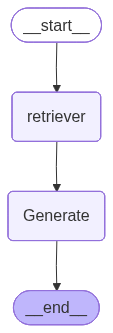

In [18]:
graph=StateGraph(state)
graph.add_node("retriever",retrieve)
graph.add_node("Generate",advanced_rag)
graph.add_edge(START,"retriever")
graph.add_edge("retriever","Generate")
graph.add_edge("Generate",END)
app=graph.compile()
app


In [19]:
res=app.invoke({"query":"GOld prices now a days"})

Retrieving documents for query: 'GOld prices now a days'
Top K: 5, Score threshold: 0.2


Batches: 100%|██████████| 1/1 [00:00<00:00, 12.39it/s]

Generated embeddings with shape: (1, 384)
Retrieved 0 documents (after filtering)
[]
REsults:  []
Context:  


LLM Response: content="I don't know. The context provided doesn't mention anything about gold prices." additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 113, 'total_tokens': 130, 'completion_time': 0.026704855, 'completion_tokens_details': None, 'prompt_time': 0.006775314, 'prompt_tokens_details': None, 'queue_time': 0.163867978, 'total_time': 0.033480169}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019ec001-2f9f-7551-bb0c-3367062c6415-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 113, 'output_tokens': 17, 'total_tokens': 130}


# Problems with RAG
    - In RAG, the Model blindly trusts the retreived Context, and its possible that the retrieved documents are not correct or not relevant for a particular query.
    - TO solve this, Corrective RAG is used by incorporating a self correction mechanism that evaluates and refines retrieved knowledge reducing errors and improving accuracy, while RAG retrieves documents and uses them to guide an LLM’s response.

In [164]:
from pydantic import BaseModel
from langchain_core.prompts import ChatPromptTemplate
import re

In [165]:
upper=0.7
lower=0.3

In [166]:
class state(TypedDict):
    query:str
    docs:List[Document]
    good_docs:List[Document]
    verdict:str
    reason:str
    strips:List[str]
    kept_strips:List[str]
    refined_context:str
    answer:str

In [167]:
def retrieve(state:state)->state:
    top_k=5
    min_score=0.2
    query=state['query']
    results=rag_retriever.retrieve(query,top_k=top_k,score_threshold=min_score)
    return {"docs":results}

In [168]:
class DocEvalScore(BaseModel):
    score: float
    reason: str

doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)

def eval_each_doc_node(state: state) -> state:
    q = state["query"]
    
    scores: List[float] = []
    reasons: List[str] = []
    good: List[Document] = []

    for d in state["docs"]:
        print("CHeck ",d)
        out = doc_eval_chain.invoke({"question": q, "chunk": d.get("content")})
        scores.append(out.score)
        reasons.append(out.reason)

       
        if out.score > lower:
            good.append(d)

    # 2) CORRECT if at least one doc > UPPER_Threshold
    if any(s > upper for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {upper}.",
        }

    # 3) INCORRECT if all docs < LOWER_TH
    if len(scores) > 0 and all(s < lower for s in scores):
        why = "No chunk was sufficient."
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {lower}. {why}",
        }

    # 4) Anything in between => AMBIGUOUS
    why = "Mixed relevance signals."
    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {upper}, but not all were < {lower}. {why}",
    }

In [169]:
# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


In [170]:
class keepordrop(BaseModel):
    keep:bool

In [171]:
filterllm=llm.with_structured_output(keepordrop)

In [172]:
filterprompt=SystemMessage(content='''
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
    ''')
def refine(state:state)->state:
    query=state['query']
    context="\n\n".join([doc['content'] for doc in state['good_docs']])
    print("Up for refinement: ",context)
    strips=decompose_to_sentences(context)
    kept:List[str]=[]
    for stp in strips:
        hyprompt=HumanMessage(content=f'''
        query:{query},
        Sentence:{stp}
        ''')
        res=filterllm.invoke([filterprompt,hyprompt])
        if res.keep:
            kept.append(stp)
    refined_context="\n".join(kept).strip()
    print("After Refinement: ",refined_context)
    return {
        "strips":strips,
        "kept_strips":kept,
        "refined_context":refined_context}

In [173]:
def advanced_rag(state:state)->state:
    query=state['query']
    context=state['refined_context']
    print("Context: ",context)
    prompt=f"""
        Use the following context to answer the question:
        Context:{context}
        Question: {query}


    Mention whether the answer was based on retrieved context. 
    If based on retrieved context, mention the source document and page number from metadata.
    
   IMPORTANT: Use only context provided to answer. If no context present, say that u don't know. Do not use your pretrained knowledge.


    """
    response=llm.invoke([HumanMessage(content=prompt)])
    print(f"LLM Response: {response}")
    return {"answer":response}

In [174]:
def fail_node(state:state)->state:
    return {"answer":"fail","reason":state['reason']}

def ambiguous_node(state:state)->state:
    return {"answer":"ambiguous","reason":state['reason']}

def route_after_eval(state:state)->state:
    if state['verdict']=='CORRECT':
        return "refine"
    elif state['verdict']=='AMBIGUOUS':
        return "ambiguous"
    else:
        return "incorrect"

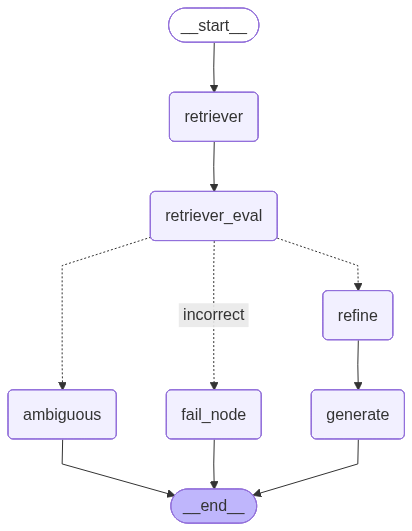

In [175]:
graph=StateGraph(state)
graph.add_node("retriever",retrieve)
graph.add_node("retriever_eval",eval_each_doc_node)

graph.add_node("fail_node",fail_node)
graph.add_node("ambiguous",ambiguous_node)
graph.add_node("refine",refine)
graph.add_node("generate",advanced_rag)
graph.add_edge(START,"retriever")
graph.add_edge("retriever","retriever_eval")
graph.add_conditional_edges("retriever_eval",route_after_eval,{
    "refine":"refine",
    "ambiguous":"ambiguous",
    "incorrect":"fail_node"
})
graph.add_edge("refine","generate")
graph.add_edge("generate",END)
graph.add_edge("fail_node",END)
graph.add_edge("ambiguous",END)
app=graph.compile()
app

In [176]:
res = app.invoke(
    {
        "query": "Life of Unified Process",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])

Retrieving documents for query: 'Life of Unified Process'
Top K: 5, Score threshold: 0.2


Batches: 100%|██████████| 1/1 [00:00<00:00,  2.25it/s]


Generated embeddings with shape: (1, 384)
Retrieved 2 documents (after filtering)
[{'id': 'doc_29ec2c51_5', 'content': '7/25/2025\n5\nLife of a Unified Process\nRUP - Summary\n•\nThe RUP is not a suitable process for all types of development but it\ndoes represent a new generation of generic processes\n•\nMost important innovation:\n•\n Combination of many views\n•\n Deployment of software is part of the process (almost ignored\nin other process models)\n•\nBased on standards\n•\n Object-oriented Modeling\n•\n Unified Modeling Language', 'metadata': {'producer': 'Acrobat Distiller 10.0.0 (Windows)', 'trapped': '', 'creationDate': "D:20250725110256+05'30'", 'file_path': '../data/pdf/IT314-Software Engineering-SPM Cont.pdf', 'subject': '', 'doc_index': 5, 'modDate': "D:20250725110256+05'30'", 'creationdate': '2025-07-25T11:02:56+05:30', 'total_pages': 10, 'author': 'DA-IICT', 'title': 'Microsoft PowerPoint - IT314-Software Engineering-SPM Cont.ppt [Compatibility Mode]', 'page': 4, 'keywo